Dataset loaded.
Number of images: 1797
Image shape: (8, 8)

Showing preprocessing and feature extraction example...


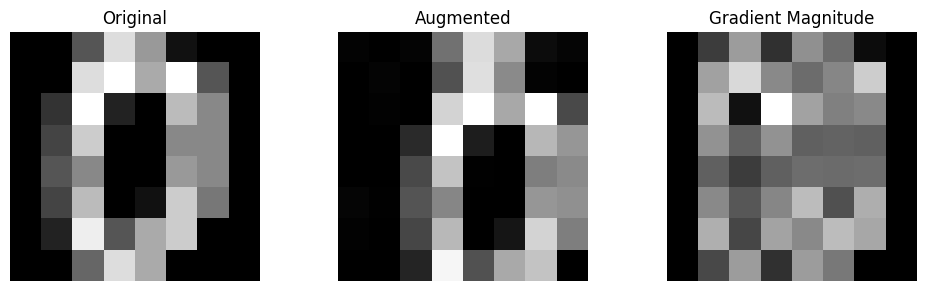


Feature extraction complete.
Feature matrix shape: (1797, 133)

=== Classification Accuracy ===
Accuracy: 0.9806

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      0.97      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       1.00      1.00      1.00        37
           6       0.97      0.97      0.97        36
           7       0.95      1.00      0.97        36
           8       0.97      0.94      0.96        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360


=== Confusion Matrix ===
[[36  0  0  0  0  0  0  0  0  0]
 [ 0 35  0  0  1  0  0  0  0  0]
 [ 0

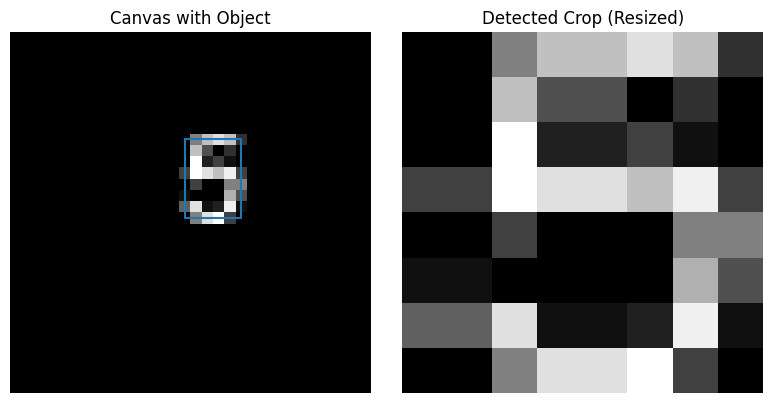


=== 3D Reasoning Demo ===
Real object height: 20.0 cm
Focal length: 800.0 px
Apparent image height: 50.0 px
Estimated depth: 320.00 cm

Pipeline complete.


In [1]:
# computer_vision_pipeline.py
"""
Computer Vision Pipeline
Goal:
- Process image input
- Extract features
- Perform classification
- Detect and localize objects
- Simulate 3D depth reasoning
- Analyze system performance

This script uses the built-in sklearn digits dataset so it runs locally
without needing external image downloads.
"""

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression


# -----------------------------
# Part 1: Image Processing
# -----------------------------
def normalize_image(img):
    """Normalize image values to range [0, 1]."""
    img = img.astype(np.float32)
    return (img - img.min()) / (img.max() - img.min() + 1e-8)


def augment_image(img):
    """
    Apply simple transformations:
    - horizontal shift
    - vertical shift
    - slight noise
    """
    aug = np.roll(img, shift=1, axis=0)
    aug = np.roll(aug, shift=1, axis=1)
    noise = np.random.normal(0, 0.03, aug.shape)
    aug = np.clip(aug + noise, 0, 1)
    return aug


def preprocess_images(images):
    """Normalize all images."""
    return np.array([normalize_image(img) for img in images])


# -----------------------------
# Part 2: Feature Extraction
# -----------------------------
def compute_gradients(img):
    """
    Compute simple gradients using finite differences.
    Returns gx, gy, and magnitude.
    """
    gx = np.zeros_like(img)
    gy = np.zeros_like(img)

    gx[:, 1:-1] = img[:, 2:] - img[:, :-2]
    gy[1:-1, :] = img[2:, :] - img[:-2, :]

    magnitude = np.sqrt(gx**2 + gy**2)
    return gx, gy, magnitude


def edge_features(img):
    """
    Extract edge/gradient-based features:
    - flattened image pixels
    - gradient magnitude
    - summary statistics
    """
    _, _, mag = compute_gradients(img)

    feat = np.concatenate([
        img.flatten(),
        mag.flatten(),
        np.array([
            img.mean(),
            img.std(),
            mag.mean(),
            mag.std(),
            mag.max(),
        ])
    ])
    return feat


def batch_extract_features(images):
    """Extract features for a batch of images."""
    return np.array([edge_features(img) for img in images])


# -----------------------------
# Part 3: Image Classification
# -----------------------------
def train_classifier(X_train, y_train):
    """
    Train a classifier on extracted features.
    SVM usually performs well on digit classification.
    """
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=5, gamma="scale"))
    ])
    model.fit(X_train, y_train)
    return model


def evaluate_classifier(model, X_test, y_test):
    """Evaluate classification model."""
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print("\n=== Classification Accuracy ===")
    print(f"Accuracy: {acc:.4f}")

    print("\n=== Classification Report ===")
    print(classification_report(y_test, y_pred))

    print("\n=== Confusion Matrix ===")
    print(confusion_matrix(y_test, y_pred))

    return y_pred, acc


# -----------------------------
# Part 4: Object Detection
# -----------------------------
def place_digit_on_canvas(digit_img, canvas_size=(32, 32), top=10, left=12):
    """
    Place an 8x8 digit image onto a larger blank canvas.
    This simulates a simple object detection task.
    """
    canvas = np.zeros(canvas_size, dtype=np.float32)
    h, w = digit_img.shape
    canvas[top:top+h, left:left+w] = digit_img
    return canvas


def detect_bounding_box(canvas, threshold=0.2):
    """
    Detect object location by thresholding non-background pixels.
    Returns bounding box as (top, left, bottom, right).
    """
    ys, xs = np.where(canvas > threshold)
    if len(xs) == 0 or len(ys) == 0:
        return None

    top = ys.min()
    bottom = ys.max()
    left = xs.min()
    right = xs.max()
    return top, left, bottom, right


def crop_and_resize_to_8x8(canvas, bbox):
    """
    Crop detected object and resize back to 8x8 using simple nearest-neighbor logic.
    Avoids requiring external dependencies.
    """
    top, left, bottom, right = bbox
    cropped = canvas[top:bottom+1, left:right+1]

    target_h, target_w = 8, 8
    src_h, src_w = cropped.shape

    # Nearest-neighbor resize
    row_idx = (np.linspace(0, src_h - 1, target_h)).astype(int)
    col_idx = (np.linspace(0, src_w - 1, target_w)).astype(int)
    resized = cropped[row_idx][:, col_idx]

    return resized


def object_detection_demo(model, original_image, true_label):
    """
    Simulate detection:
    - Place digit on large canvas
    - Detect bounding box
    - Crop object
    - Extract features
    - Classify object
    """
    canvas = place_digit_on_canvas(original_image, top=9, left=14)
    bbox = detect_bounding_box(canvas)

    if bbox is None:
        print("No object detected.")
        return None

    cropped = crop_and_resize_to_8x8(canvas, bbox)
    features = edge_features(cropped).reshape(1, -1)
    pred = model.predict(features)[0]

    print("\n=== Object Detection Demo ===")
    print(f"True label: {true_label}")
    print(f"Predicted label from detected object: {pred}")
    print(f"Detected bounding box (top, left, bottom, right): {bbox}")

    return canvas, bbox, cropped, pred


# -----------------------------
# Part 5: 3D Reasoning
# -----------------------------
def estimate_depth(real_height_cm, focal_length_px, apparent_height_px):
    """
    Simple monocular depth estimation using similar-triangle geometry:
    depth = (real_height * focal_length) / apparent_height
    """
    if apparent_height_px <= 0:
        return None
    return (real_height_cm * focal_length_px) / apparent_height_px


def depth_reasoning_demo():
    """
    Simulate depth estimation from object size in an image.
    """
    real_height_cm = 20.0      # example known object height
    focal_length_px = 800.0    # hypothetical camera focal length
    apparent_height_px = 50.0  # measured pixel height in image

    depth_cm = estimate_depth(real_height_cm, focal_length_px, apparent_height_px)

    print("\n=== 3D Reasoning Demo ===")
    print(f"Real object height: {real_height_cm} cm")
    print(f"Focal length: {focal_length_px} px")
    print(f"Apparent image height: {apparent_height_px} px")
    print(f"Estimated depth: {depth_cm:.2f} cm")

    return depth_cm


# -----------------------------
# Visualization helpers
# -----------------------------
def show_processing_example(img):
    """Visualize original, augmented, and gradient magnitude."""
    aug = augment_image(img)
    _, _, mag = compute_gradients(img)

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original")

    axes[1].imshow(aug, cmap="gray")
    axes[1].set_title("Augmented")

    axes[2].imshow(mag, cmap="gray")
    axes[2].set_title("Gradient Magnitude")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def show_detection_result(canvas, bbox, cropped):
    """Visualize detection result."""
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(canvas, cmap="gray")
    axes[0].set_title("Canvas with Object")

    if bbox is not None:
        top, left, bottom, right = bbox
        rect_x = [left, right, right, left, left]
        rect_y = [top, top, bottom, bottom, top]
        axes[0].plot(rect_x, rect_y)

    axes[1].imshow(cropped, cmap="gray")
    axes[1].set_title("Detected Crop (Resized)")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# -----------------------------
# Main
# -----------------------------
def main():
    np.random.seed(42)

    # Load dataset
    digits = load_digits()
    images = digits.images
    labels = digits.target

    print("Dataset loaded.")
    print(f"Number of images: {len(images)}")
    print(f"Image shape: {images[0].shape}")

    # Preprocess
    images = preprocess_images(images)

    # Show one processing example
    print("\nShowing preprocessing and feature extraction example...")
    show_processing_example(images[0])

    # Feature extraction
    X = batch_extract_features(images)
    y = labels

    print("\nFeature extraction complete.")
    print(f"Feature matrix shape: {X.shape}")

    # Split data
    X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
        X, y, images, test_size=0.2, random_state=42, stratify=y
    )

    # Train classifier
    model = train_classifier(X_train, y_train)

    # Evaluate classifier
    y_pred, acc = evaluate_classifier(model, X_test, y_test)

    # Detection demo on one test image
    sample_img = img_test[0]
    sample_label = y_test[0]

    detection_output = object_detection_demo(model, sample_img, sample_label)
    if detection_output is not None:
        canvas, bbox, cropped, pred = detection_output
        show_detection_result(canvas, bbox, cropped)

    # 3D reasoning demo
    depth_reasoning_demo()

    print("\nPipeline complete.")


if __name__ == "__main__":
    main()

# Computer Vision Pipeline

## Goal
The goal of this system is to interpret visual data by:
- Loading and preprocessing images
- Extracting meaningful features
- Classifying images
- Detecting and localizing objects
- Simulating basic 3D reasoning

---

## Part 1: Image Processing (25.1–25.2)

### Processing Steps
The system begins by loading image data (handwritten digits dataset).

Preprocessing includes:

1. **Normalization**
   - Pixel values are scaled to the range [0, 1]
   - This ensures consistency across inputs

2. **Transformations**
   - Image shifting (horizontal and vertical)
   - Addition of small random noise
   - These simulate real-world variation

### Importance
Preprocessing improves model performance by:
- Reducing noise
- Standardizing inputs
- Making feature extraction more reliable

---

## Part 2: Feature Extraction (25.3)

### Features Used
The system extracts:

1. **Raw pixel values**
2. **Gradient features**
   - Horizontal and vertical gradients
   - Gradient magnitude (edge strength)
3. **Statistical features**
   - Mean intensity
   - Standard deviation
   - Mean gradient
   - Max gradient

### Why These Features Matter
- Gradients and edges represent object shape
- Shape is critical for identifying visual patterns (e.g., digits)
- Statistical features help summarize image structure

---

## Part 3: Image Classification (25.4)

### Model
A Support Vector Machine (SVM) is used.

### Steps
1. Extract features
2. Split data into training/testing sets
3. Train model
4. Evaluate performance

### Performance Metrics
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

### Interpretation
- High accuracy indicates good overall performance
- Confusion matrix shows which classes are misclassified

---

## Part 4: Object Detection (25.5)

### Approach
A simple detection system is implemented:

1. Place an object on a larger canvas
2. Detect non-zero pixels using thresholding
3. Compute bounding box
4. Crop detected object
5. Resize to original size
6. Classify the cropped object

### Key Idea
Object detection solves two problems:
- Localization (where is the object?)
- Classification (what is the object?)

---

## Part 5: 3D Reasoning (25.6)

### Depth Estimation Formula
Depth is estimated using:

Depth = (Real Height × Focal Length) / Apparent Height

### Explanation
- If an object appears smaller in the image, it is farther away
- This uses simple geometry (similar triangles)

### Limitation
- Requires known object size
- Not robust compared to modern deep learning depth models

---

## Part 6: System Design (25.7)

### Proposed Application: Smart Warehouse Vision System

### Functionality
- Detect packages on conveyor belts
- Classify package types
- Locate objects for robotic arms
- Estimate distance for sorting

### Benefits
- Automation of logistics
- Faster processing
- Reduced human error

### Possible Improvements
- Use CNNs instead of handcrafted features
- Implement YOLO for detection
- Add depth cameras for better 3D reasoning
- Train on larger datasets

# Reflection Questions

## Which features were most useful?
The most useful features were the gradient and edge-based features. These captured the structure and shape of the objects more effectively than raw pixel values. Since visual recognition relies heavily on object boundaries, gradients provided critical information for distinguishing between classes.

## What challenges arose in classification?
One major challenge was that some classes are visually similar. Small variations in shape, noise, or writing style can make different classes appear alike. Additionally, handcrafted features may not capture all complex patterns, limiting classification accuracy compared to deep learning approaches.

## How difficult is object detection compared to classification?
Object detection is significantly more difficult than classification. Classification only requires identifying what an object is, assuming it is already centered and visible. Object detection, however, requires both locating the object in the image and then classifying it, which introduces additional complexity and potential sources of error.

## What limitations exist in real-world vision systems?
Real-world vision systems face several limitations:
- Variations in lighting conditions
- Occlusion (objects partially hidden)
- Background noise and clutter
- Motion blur
- Differences in scale and perspective
- Limited or biased training data
- High computational requirements for real-time processing

These challenges make it difficult for systems to generalize perfectly outside controlled environments.